# Simulasi Fuzzy Inference System (FIS)

Notebook ini mengimplementasikan **Fuzzy Inference System (FIS)** yang fleksibel, *scalable*, dan modular untuk mata kuliah Matematika Sistem Kendali. Sistem ini mendukung dua metode inferensi utama:
1. **Metode Sugeno** (Defuzzifikasi: *Weighted Average*)
2. **Metode Mamdani** (Defuzzifikasi: *Centroid / Center of Gravity*)

### Fitur Utama:
- **Seleksi Metode**: Pengguna dapat memilih metode inferensi `'sugeno'` atau `'mamdani'` secara eksplisit.
- **Visualisasi Lengkap**: Grafik fungsi keanggotaan dengan titik potong input *crisp* serta grafik proses defuzzifikasi (arsiran daerah *Centroid* atau *stem plot Weighted Average*).
- **Scalable & Modular**: Struktur kelas berbasis OOP memudahkan pembuatan studi kasus baru tanpa perlu merombak kode fondasi.
- **Tampilan Konsisten**: Format teks keluaran terminal dipertahankan sesuai kode program awal dengan penambahan informasi metode yang informatif.

In [17]:
%pip install -r ../requirements.txt

import numpy as np
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### 1. Membership Function (Fungsi Keanggotaan)
Fungsi keanggotaan memetakan nilai tegas (*crisp*) ke dalam derajat keanggotaan fuzzy $\mu \in [0, 1]$.
- `LinearDownMF`: Fungsi linier monoton turun
- `LinearUpMF`: Fungsi linier monoton naik
- `TriangularMF`: Fungsi segitiga
- `TrapezoidalMF`: Fungsi trapesium

In [9]:
class MembershipFunction:
    def __call__(self, x):
        raise NotImplementedError

class LinearDownMF(MembershipFunction):
    """MF: Linear Down (Monoton Turun)"""
    def __init__(self, a, b):
        self.a = a  # Batas bawah (mu = 1)
        self.b = b  # Batas atas (mu = 0)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return np.clip((self.b - x) / (self.b - self.a), 0.0, 1.0)

class LinearUpMF(MembershipFunction):
    """MF: Linear Up (Monoton Naik)"""
    def __init__(self, a, b):
        self.a = a  # Batas bawah (mu = 0)
        self.b = b  # Batas atas (mu = 1)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        return np.clip((x - self.a) / (self.b - self.a), 0.0, 1.0)

class TriangularMF(MembershipFunction):
    """MF: Triangular (Segitiga)"""
    def __init__(self, a, b, c):
        self.a = a  # Kaki kiri (mu = 0)
        self.b = b  # Puncak (mu = 1)
        self.c = c  # Kaki kanan (mu = 0)

    def __call__(self, x):
        x = np.array(x, dtype=float)
        res = np.zeros_like(x)
        mask1 = (x >= self.a) & (x <= self.b)
        if self.b > self.a:
            res[mask1] = (x[mask1] - self.a) / (self.b - self.a)
        mask2 = (x > self.b) & (x <= self.c)
        if self.c > self.b:
            res[mask2] = (self.c - x[mask2]) / (self.c - self.b)
        return np.clip(res, 0.0, 1.0)

class TrapezoidalMF(MembershipFunction):
    """MF: Trapezoidal (Trapesium)"""
    def __init__(self, a, b, c, d):
        self.a, self.b, self.c, self.d = a, b, c, d

    def __call__(self, x):
        x = np.array(x, dtype=float)
        res = np.zeros_like(x)
        mask1 = (x >= self.a) & (x < self.b)
        if self.b > self.a:
            res[mask1] = (x[mask1] - self.a) / (self.b - self.a)
        mask2 = (x >= self.b) & (x <= self.c)
        res[mask2] = 1.0
        mask3 = (x > self.c) & (x <= self.d)
        if self.d > self.c:
            res[mask3] = (self.d - x[mask3]) / (self.d - self.c)
        return np.clip(res, 0.0, 1.0)

### 2. Variabel Fuzzy
Kelas `FuzzyVariable` mewakili variabel linguistik (input atau output), rentang semesta pembicaraan (*domain*), satuan, dan himpunan fuzzy yang terasosiasi dengannya.

In [10]:
class FuzzyVariable:
    def __init__(self, name, domain_min, domain_max, var_type='input', unit=''):
        self.name = name
        self.domain = (domain_min, domain_max)
        self.var_type = var_type  # 'input' atau 'output'
        self.unit = unit
        self.sets = {}  # {nama_himpunan: membership_function}

    def add_set(self, set_name, mf):
        self.sets[set_name] = mf
        return self

    def fuzzify(self, value):
        return {set_name: float(mf(value)) for set_name, mf in self.sets.items()}

### 3. Fuzzy Rules (Aturan Fuzzy)
Kelas `FuzzyRule` memodelkan aturan implikasi fuzzy IF-THEN:
- **Anteseden**: Daftar kondisi `[('nama_var', 'nama_set'), ...]` yang dihubungkan dengan operator `AND` (operasi $\min$) atau `OR` (operasi $\max$).
- **Konsekuen**:
  - Untuk **Mamdani**: Mereferensikan himpunan linguistik fuzzy pada variabel output (`consequent_var`, `consequent_set`).
  - Untuk **Sugeno**: Menggunakan fungsi invers $z = f(\alpha)$ atau nilai skalar konstanta (`inverse_func`).

In [11]:
class FuzzyRule:
    def __init__(self, antecedents, operator, consequent_var, consequent_set, inverse_func=None):
        self.antecedents = antecedents          # [('nama_var', 'nama_set'), ...]
        self.operator = operator.upper()        # 'AND' atau 'OR'
        self.consequent_var = consequent_var    # Nama variabel output
        self.consequent_set = consequent_set    # Nama himpunan konsekuen (Mamdani)
        self.inverse_func = inverse_func        # Fungsi z = f(alpha) atau skalar z untuk Sugeno

    def evaluate(self, fuzzified_inputs):
        doms = [fuzzified_inputs[var][set_name] for var, set_name in self.antecedents]
        if self.operator == 'AND':
            return min(doms)
        elif self.operator == 'OR':
            return max(doms)
        raise ValueError(f"Operator '{self.operator}' tidak didukung. Gunakan 'AND' atau 'OR'.")

### 4. Fuzzy Inference System (Sugeno & Mamdani)
Kelas `FuzzyInferenceSystem` merupakan mesin inferensi utama yang mendukung metode `'sugeno'` atau `'mamdani'`:
1. **Fuzzifikasi**: Menghitung derajat keanggotaan nilai crisp pada setiap variabel masukan.
2. **Evaluasi Aturan**: Menghitung firing strength $\alpha_i$ untuk setiap aturan.
3. **Defuzzifikasi**:
   - **Metode Sugeno** (*Weighted Average*):
     $$z^* = \frac{\sum_{i=1}^n \alpha_i \cdot z_i}{\sum_{i=1}^n \alpha_i}$$
   - **Metode Mamdani** (*Centroid / Center of Gravity*):
     Memotong fungsi keanggotaan konsekuen sebesar $\alpha_i$ (metode *min*), menggabungkannya dengan agregasi *max*, lalu menghitung titik beratnya secara numerik:
     $$z^* = \frac{\int z \cdot \mu_{agg}(z) \, dz}{\int \mu_{agg}(z) \, dz} \approx \frac{\sum z_k \cdot \mu_{agg}(z_k)}{\sum \mu_{agg}(z_k)}$$

In [12]:
class FuzzyInferenceSystem:
    def __init__(self, method='sugeno'):
        method_clean = method.lower().strip()
        if method_clean not in ['sugeno', 'mamdani']:
            raise ValueError(f"Metode '{method}' tidak valid! FIS hanya mendukung metode 'sugeno' atau 'mamdani'.")
        self.method = method_clean
        self.variables = {}
        self.rules = []

    def add_variable(self, var):
        self.variables[var.name] = var
        return self

    def add_rule(self, rule):
        self.rules.append(rule)
        return self

    def compute(self, crisp_inputs):
        # 1. Fuzzifikasi
        fuzzified = {var_name: self.variables[var_name].fuzzify(val)
                     for var_name, val in crisp_inputs.items()}

        # 2. Evaluasi Aturan & Defuzzifikasi berdasarkan metode
        if self.method == 'sugeno':
            rule_outputs = []
            for rule in self.rules:
                alpha = rule.evaluate(fuzzified)
                # Evaluasi nilai z konsekuen (fungsi atau skalar)
                if callable(rule.inverse_func):
                    try:
                        z = rule.inverse_func(alpha)
                    except TypeError:
                        z = rule.inverse_func(alpha, crisp_inputs)
                elif isinstance(rule.inverse_func, (int, float)):
                    z = float(rule.inverse_func)
                else:
                    raise ValueError(f"Aturan dengan konsekuen {rule.consequent_set} membutuhkan inverse_func/nilai skalar untuk Sugeno.")
                rule_outputs.append((alpha, z))

            # Defuzzifikasi: Weighted Average
            total_alpha = sum(alpha for alpha, z in rule_outputs)
            z_star = sum(alpha * z for alpha, z in rule_outputs) / total_alpha if total_alpha > 0 else 0.0
            return z_star, rule_outputs, fuzzified

        elif self.method == 'mamdani':
            out_var_name = self.rules[0].consequent_var
            out_var = self.variables[out_var_name]

            # Domain diskritisasi untuk integrasi numerik defuzzifikasi Centroid
            z_vals = np.linspace(out_var.domain[0], out_var.domain[1], 1001)
            aggregated = np.zeros_like(z_vals)
            rule_outputs = []

            for rule in self.rules:
                alpha = rule.evaluate(fuzzified)
                mf = out_var.sets[rule.consequent_set]
                clipped_mf = np.minimum(alpha, mf(z_vals))
                aggregated = np.maximum(aggregated, clipped_mf)
                rule_outputs.append((alpha, rule.consequent_var, rule.consequent_set))

            # Defuzzifikasi: Centroid (Center of Gravity)
            sum_agg = np.sum(aggregated)
            if sum_agg > 0:
                z_star = float(np.sum(z_vals * aggregated) / sum_agg)
            else:
                z_star = float(np.mean(out_var.domain))

            return z_star, rule_outputs, fuzzified

### 5. Format Output & Modul Visualisasi Grafik Fuzzy
Bagian ini menyediakan utilitas cetak hasil dan visualisasi:
- `print_simulation_results()`: Menampilkan laporan hasil teks terminal-based dengan format asli yang rapi.
- `plot_membership_functions()`: Memvisualisasikan seluruh kurva himpunan keanggotaan dan menandai posisi input crisp.
- `plot_defuzzification()`: Menampilkan kurva pemotongan area fuzzy hasil agregasi dan garis *Centroid* (Mamdani) atau *stem plot* firing strength dan garis *Weighted Average* (Sugeno).
- `run_simulation()`: Fungsi ringkas untuk menjalankan inferensi, mencetak laporan teks, dan memplot grafik sekaligus.

In [13]:
def print_simulation_results(fis, crisp_inputs, z_star, rule_outputs, fuzzified, title="HASIL SIMULASI FUZZY INFERENCE SYSTEM (KASUS ABC)", unit="kemasan/hari"):
    method_label = "Sugeno (Weighted Average)" if fis.method == 'sugeno' else "Mamdani (Centroid)"
    input_str = ", ".join([f"{k} = {v}" for k, v in crisp_inputs.items()])

    print("=" * 60)
    print(f"      {title}")
    print("=" * 60)
    print(f"Metode FIS  : {method_label}")
    print(f"Input Crisp : {input_str}")
    print("-" * 60)
    print("1. Fuzzifikasi:")
    for var, sets in fuzzified.items():
        print(f"   [{var}] -> " + ", ".join([f"{k}: {v:.4f}" for k, v in sets.items()]))
    print("-" * 60)
    if fis.method == 'sugeno':
        print("2. Evaluasi Aturan (Firing Strength & z_i):")
        for idx, (alpha, z) in enumerate(rule_outputs, start=1):
            print(f"   * Rule R{idx} -> alpha_{idx} = {alpha:.4f}, z_{idx} = {z:.2f}")
    else:
        print("2. Evaluasi Aturan (Firing Strength & Konsekuen):")
        for idx, (alpha, var_name, set_name) in enumerate(rule_outputs, start=1):
            print(f"   * Rule R{idx} -> alpha_{idx} = {alpha:.4f}, Konsekuen: {var_name} {set_name}")
    print("-" * 60)
    print(f"3. Hasil Akhir Defuzzifikasi: z* = {z_star:.2f} {unit}")
    print("=" * 60)

def plot_membership_functions(fis, crisp_inputs=None):
    """Menampilkan grafik fungsi keanggotaan untuk setiap variabel fuzzy beserta titik potong input crisp."""
    n_vars = len(fis.variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(9, 2.8 * n_vars), sharey=True)
    if n_vars == 1:
        axes = [axes]

    palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for ax, (var_name, var) in zip(axes, fis.variables.items()):
        x_vals = np.linspace(var.domain[0], var.domain[1], 500)
        for i, (set_name, mf) in enumerate(var.sets.items()):
            color = palette[i % len(palette)]
            y_vals = mf(x_vals)
            ax.plot(x_vals, y_vals, label=set_name, linewidth=2, color=color)

        unit_str = f" ({var.unit})" if var.unit else ""
        ax.set_title(f"Fungsi Keanggotaan: {var_name}{unit_str}", fontsize=11, fontweight='bold')
        ax.set_xlabel(f"{var_name}{unit_str}")
        ax.set_ylabel(r"Derajat ($\mu$)")
        ax.set_ylim(-0.05, 1.08)
        ax.grid(True, linestyle=':', alpha=0.6)

        # Plot garis nilai input crisp dan anotasi derajat keanggotaan
        if crisp_inputs and var_name in crisp_inputs:
            x_val = crisp_inputs[var_name]
            ax.axvline(x_val, color='#e74c3c', linestyle='--', linewidth=1.8, label=f"Input: {x_val}")
            for set_name, mf in var.sets.items():
                mu_val = float(mf(x_val))
                ax.plot(x_val, mu_val, 'o', color='#e74c3c', markersize=6)
                ax.annotate(f"{set_name}: {mu_val:.2f}",
                            (x_val, mu_val),
                            textcoords="offset points",
                            xytext=(8, 4),
                            fontsize=9,
                            fontweight='bold',
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#e74c3c", alpha=0.8))
        ax.legend(loc='upper right', framealpha=0.85)

    plt.tight_layout()
    plt.show()

def plot_defuzzification(fis, crisp_inputs, z_star, rule_outputs, fuzzified):
    """Menampilkan grafik proses inferensi dan defuzzifikasi (Mamdani Centroid atau Sugeno Weighted Average)."""
    out_var_name = fis.rules[0].consequent_var
    out_var = fis.variables[out_var_name]
    z_min, z_max = out_var.domain
    z_vals = np.linspace(z_min, z_max, 1000)

    fig, ax = plt.subplots(figsize=(9, 4.2))

    if fis.method == 'mamdani':
        for set_name, mf in out_var.sets.items():
            ax.plot(z_vals, mf(z_vals), '--', alpha=0.45, linewidth=1.5, label=f"MF Asli: {set_name}")

        aggregated = np.zeros_like(z_vals)
        for alpha, v_name, set_name in rule_outputs:
            mf = out_var.sets[set_name]
            clipped = np.minimum(alpha, mf(z_vals))
            aggregated = np.maximum(aggregated, clipped)

        ax.fill_between(z_vals, aggregated, color='#2ecc71', alpha=0.35, label='Area Agregasi Terpotong (Max-Min)')
        ax.plot(z_vals, aggregated, color='#27ae60', linewidth=2)

        unit_str = f" {out_var.unit}" if out_var.unit else ""
        ax.axvline(z_star, color='#c0392b', linestyle='-', linewidth=2.5,
                   label=f"Centroid z* = {z_star:.2f}{unit_str}")
        ax.set_title(f"Defuzzifikasi Mamdani (Metode Centroid / Center of Gravity) - {out_var_name}", fontsize=11, fontweight='bold')

    elif fis.method == 'sugeno':
        rule_z = [z for alpha, z in rule_outputs]
        rule_a = [alpha for alpha, z in rule_outputs]

        markerline, stemlines, baseline = ax.stem(rule_z, rule_a, linefmt='b-', markerfmt='bo', basefmt='k-')
        plt.setp(stemlines, linewidth=1.8)
        plt.setp(markerline, markersize=8)

        for i, (alpha, z) in enumerate(rule_outputs, 1):
            ax.annotate(f"R{i} (z={z:.1f}, α={alpha:.2f})", (z, alpha),
                        textcoords="offset points", xytext=(0, 6), ha='center', fontsize=8.5, fontweight='bold')

        unit_str = f" {out_var.unit}" if out_var.unit else ""
        ax.axvline(z_star, color='#c0392b', linestyle='-', linewidth=2.5,
                   label=f"Weighted Avg z* = {z_star:.2f}{unit_str}")
        ax.set_title(f"Defuzzifikasi Sugeno (Metode Weighted Average) - {out_var_name}", fontsize=11, fontweight='bold')
        ax.set_xlim(z_min - 0.05 * (z_max - z_min), z_max + 0.05 * (z_max - z_min))

    unit_str = f" ({out_var.unit})" if out_var.unit else ""
    ax.set_xlabel(f"{out_var_name}{unit_str}")
    ax.set_ylabel(r"Firing Strength ($\alpha$) / Keanggotaan")
    ax.set_ylim(-0.05, 1.1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

def run_simulation(fis, crisp_inputs, title="HASIL SIMULASI FUZZY INFERENCE SYSTEM"):
    """Menjalankan komputasi FIS, mencetak teks laporan, dan memplot visualisasi lengkap."""
    z_star, rule_outputs, fuzzified = fis.compute(crisp_inputs)
    out_var_name = fis.rules[0].consequent_var
    unit = fis.variables[out_var_name].unit if hasattr(fis.variables[out_var_name], 'unit') else ""
    print_simulation_results(fis, crisp_inputs, z_star, rule_outputs, fuzzified, title=title, unit=unit)
    plot_membership_functions(fis, crisp_inputs)
    plot_defuzzification(fis, crisp_inputs, z_star, rule_outputs, fuzzified)
    return z_star, rule_outputs, fuzzified

### 6. Studi Kasus 1: Produksi Makanan Kaleng ABC
Penerapan sistem inferensi fuzzy pada penentuan jumlah produksi makanan kaleng ABC berdasarkan dua variabel input:
- **Permintaan**: 1000 s.d. 5000 kemasan/hari (Himpunan: `TURUN`, `NAIK`)
- **Persediaan**: 100 s.d. 600 kemasan/hari (Himpunan: `SEDIKIT`, `BANYAK`)
- **Produksi (Output)**: 2000 s.d. 7000 kemasan/hari (Himpunan: `BERKURANG`, `BERTAMBAH`)

**Basis Aturan (*Rule Base*):**
- [R1] IF Permintaan TURUN AND Persediaan BANYAK THEN Produksi BERKURANG
- [R2] IF Permintaan TURUN AND Persediaan SEDIKIT THEN Produksi BERKURANG
- [R3] IF Permintaan NAIK AND Persediaan BANYAK THEN Produksi BERTAMBAH
- [R4] IF Permintaan NAIK AND Persediaan SEDIKIT THEN Produksi BERTAMBAH

In [14]:
def build_abc_case_fis(method='sugeno'):
    """Membangun FIS Kasus Produksi Makanan Kaleng ABC dengan opsi metode 'sugeno' atau 'mamdani'."""
    fis = FuzzyInferenceSystem(method=method)

    # --- Variabel Permintaan (1000 - 5000) ---
    permintaan = FuzzyVariable('Permintaan', 1000, 5000, var_type='input', unit='kemasan/hari')
    permintaan.add_set('TURUN', LinearDownMF(1000, 5000))
    permintaan.add_set('NAIK', LinearUpMF(1000, 5000))
    fis.add_variable(permintaan)

    # --- Variabel Persediaan (100 - 600) ---
    persediaan = FuzzyVariable('Persediaan', 100, 600, var_type='input', unit='kemasan/hari')
    persediaan.add_set('SEDIKIT', LinearDownMF(100, 600))
    persediaan.add_set('BANYAK', LinearUpMF(100, 600))
    fis.add_variable(persediaan)

    # --- C. Variabel Produksi (2000 - 7000) ---
    produksi = FuzzyVariable('Produksi', 2000, 7000, var_type='output', unit='kemasan/hari')
    produksi.add_set('BERKURANG', LinearDownMF(2000, 7000))
    produksi.add_set('BERTAMBAH', LinearUpMF(2000, 7000))
    fis.add_variable(produksi)

    # --- D. Fungsi Invers z = f(alpha) untuk Sugeno ---
    inv_berkurang = lambda alpha: 7000.0 - (alpha * 5000.0)
    inv_bertambah = lambda alpha: 2000.0 + (alpha * 5000.0)

    # --- E. Rule Base (R1 - R4) ---
    fis.add_rule(FuzzyRule([('Permintaan', 'TURUN'), ('Persediaan', 'BANYAK')], 'AND', 'Produksi', 'BERKURANG', inv_berkurang))
    fis.add_rule(FuzzyRule([('Permintaan', 'TURUN'), ('Persediaan', 'SEDIKIT')], 'AND', 'Produksi', 'BERKURANG', inv_berkurang))
    fis.add_rule(FuzzyRule([('Permintaan', 'NAIK'), ('Persediaan', 'BANYAK')], 'AND', 'Produksi', 'BERTAMBAH', inv_bertambah))
    fis.add_rule(FuzzyRule([('Permintaan', 'NAIK'), ('Persediaan', 'SEDIKIT')], 'AND', 'Produksi', 'BERTAMBAH', inv_bertambah))

    return fis

### 7. Simulasi Kasus ABC: Metode Sugeno & Mamdani
Pengujian dilakukan dengan nilai input:
- **Permintaan** = 4000
- **Persediaan** = 300

Berikut adalah perbandingan eksekusi dan visualisasi untuk kedua metode.

>>> EKSEKUSI SIMULASI: METODE SUGENO <<<
      HASIL SIMULASI FIS SUGENO (KASUS ABC)
Metode FIS  : Sugeno (Weighted Average)
Input Crisp : Permintaan = 4000, Persediaan = 300
------------------------------------------------------------
1. Fuzzifikasi:
   [Permintaan] -> TURUN: 0.2500, NAIK: 0.7500
   [Persediaan] -> SEDIKIT: 0.6000, BANYAK: 0.4000
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & z_i):
   * Rule R1 -> alpha_1 = 0.2500, z_1 = 5750.00
   * Rule R2 -> alpha_2 = 0.2500, z_2 = 5750.00
   * Rule R3 -> alpha_3 = 0.4000, z_3 = 4000.00
   * Rule R4 -> alpha_4 = 0.6000, z_4 = 5000.00
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 4983.33 kemasan/hari


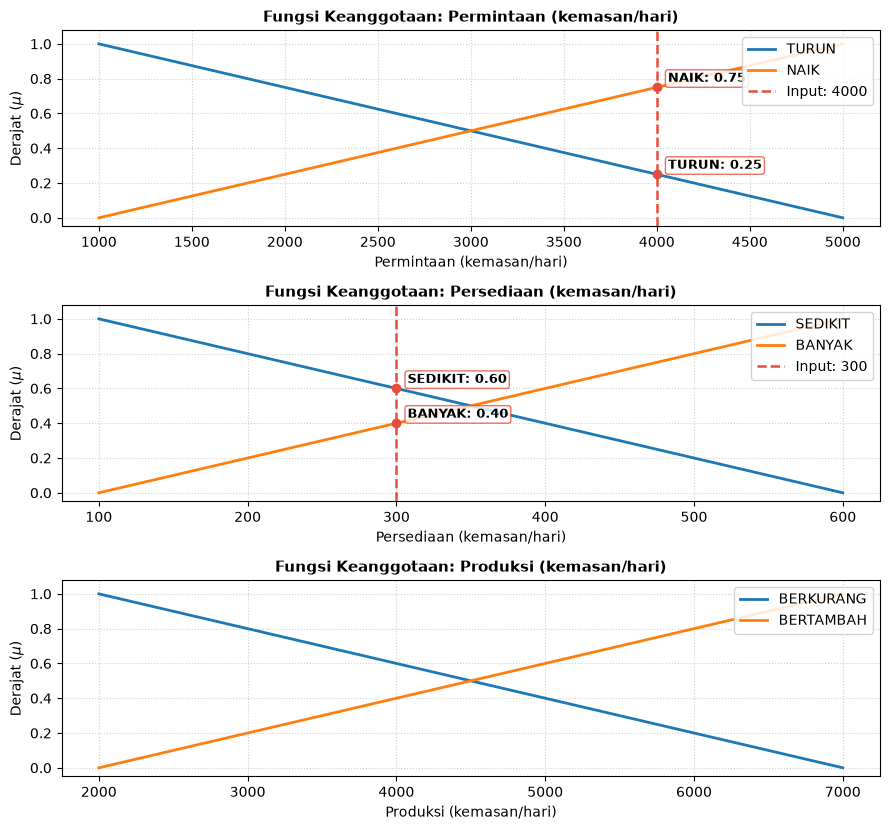

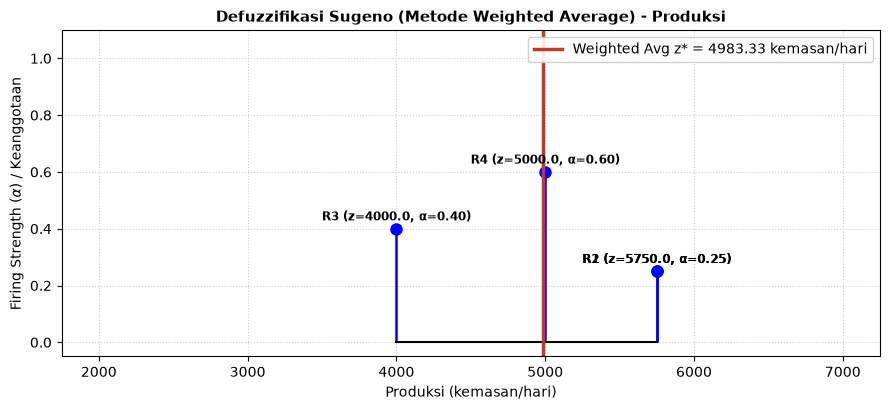



>>> EKSEKUSI SIMULASI: METODE MAMDANI <<<
      HASIL SIMULASI FIS MAMDANI (KASUS ABC)
Metode FIS  : Mamdani (Centroid)
Input Crisp : Permintaan = 4000, Persediaan = 300
------------------------------------------------------------
1. Fuzzifikasi:
   [Permintaan] -> TURUN: 0.2500, NAIK: 0.7500
   [Persediaan] -> SEDIKIT: 0.6000, BANYAK: 0.4000
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & Konsekuen):
   * Rule R1 -> alpha_1 = 0.2500, Konsekuen: Produksi BERKURANG
   * Rule R2 -> alpha_2 = 0.2500, Konsekuen: Produksi BERKURANG
   * Rule R3 -> alpha_3 = 0.4000, Konsekuen: Produksi BERTAMBAH
   * Rule R4 -> alpha_4 = 0.6000, Konsekuen: Produksi BERTAMBAH
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 4954.60 kemasan/hari


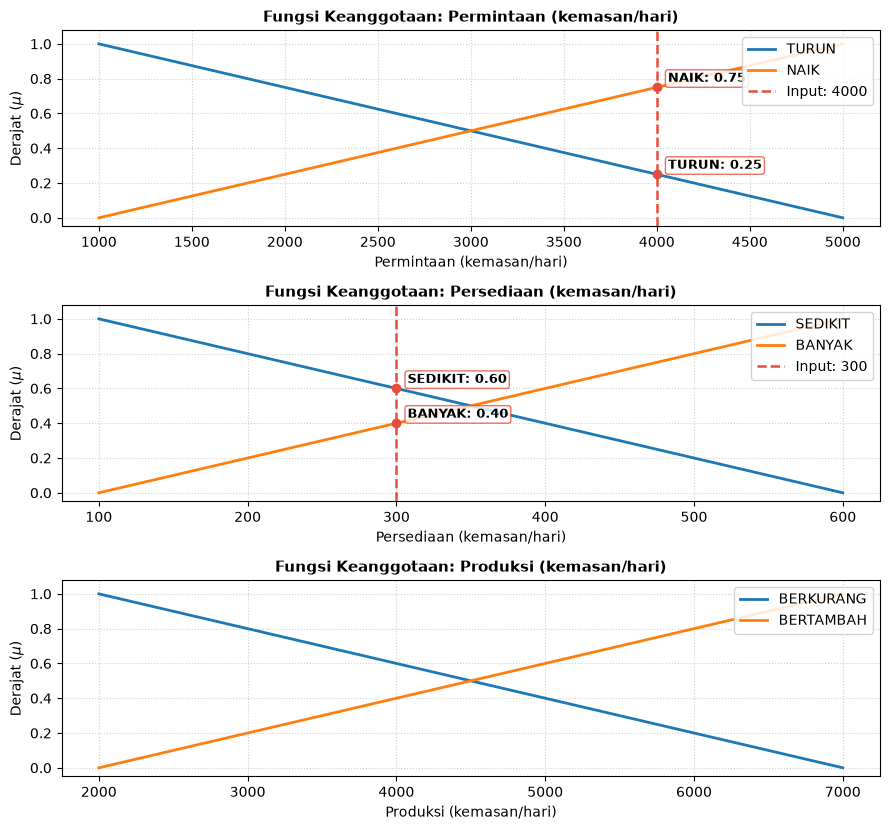

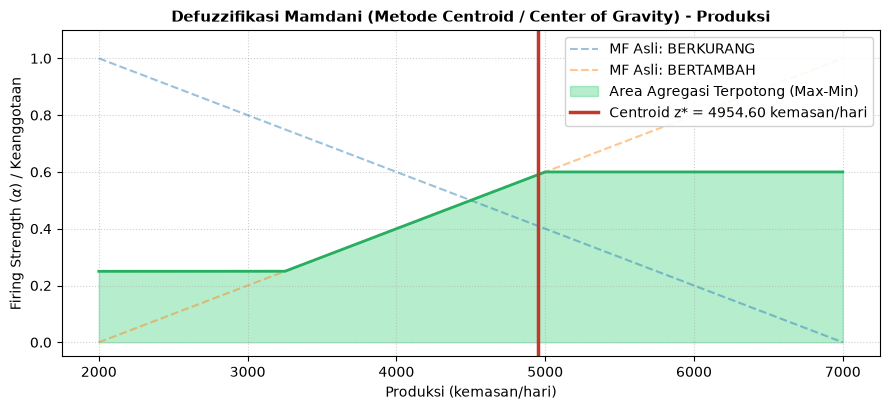

In [15]:
input_data_abc = {'Permintaan': 4000, 'Persediaan': 300}

print(">>> EKSEKUSI SIMULASI: METODE SUGENO <<<")
fis_sugeno = build_abc_case_fis(method='sugeno')
z_sugeno, _, _ = run_simulation(fis_sugeno, input_data_abc, title="HASIL SIMULASI FIS SUGENO (KASUS ABC)")

print("\n" + "=" * 60 + "\n")

print(">>> EKSEKUSI SIMULASI: METODE MAMDANI <<<")
fis_mamdani = build_abc_case_fis(method='mamdani')
z_mamdani, _, _ = run_simulation(fis_mamdani, input_data_abc, title="HASIL SIMULASI FIS MAMDANI (KASUS ABC)")

### 8. Panduan Menambahkan Studi Kasus Baru (Scalable Design)
Arsitektur kode ini dirancang *scalable* dan modular sehingga Anda dapat membuat studi kasus kendali fuzzy lainnya hanya dengan 4 langkah sederhana:

```python
# Langkah 1: Inisialisasi FIS dengan metode yang diinginkan ('sugeno' atau 'mamdani')
fis = FuzzyInferenceSystem(method='mamdani')

# Langkah 2: Buat Variabel Fuzzy (Input & Output) dan tambahkan himpunan keanggotaannya
var_in = FuzzyVariable('NamaInput', min_val, max_val, var_type='input', unit='satuan')
var_in.add_set('RENDAH', TriangularMF(a, b, c))
var_in.add_set('TINGGI', LinearUpMF(a, b))
fis.add_variable(var_in)

# Langkah 3: Tambahkan Aturan Fuzzy
rule = FuzzyRule(antecedents=[('NamaInput', 'RENDAH')],
                 operator='AND',
                 consequent_var='NamaOutput',
                 consequent_set='HimpunanOutput',
                 inverse_func=nilai_atau_fungsi_sugeno)
fis.add_rule(rule)

# Langkah 4: Hitung dan Tampilkan Grafik
run_simulation(fis, {'NamaInput': nilai_crisp})
```

### 9. Contoh Studi Kasus Baru: Sistem Kendali Kecepatan Motor Kipas Pendingin
Sebagai pembuktian kemudahan penambahan studi kasus baru pada bidang **Matematika Sistem Kendali**, berikut adalah implementasi sistem kendali kecepatan putaran kipas (*cooling fan speed controller*) berdasarkan variabel suhu:
- **Input**: `Suhu` ($0 - 100\ ^\circ\text{C}$)
  - `DINGIN`: Trapesium (0, 0, 25, 40)
  - `NORMAL`: Segitiga (30, 50, 70)
  - `PANAS`: Trapesium (60, 75, 100, 100)
- **Output**: `Kecepatan` ($0 - 1500\ \text{RPM}$)
  - `LAMBAT`: Trapesium (0, 0, 300, 600) / target Sugeno: 300 RPM
  - `SEDANG`: Segitiga (400, 750, 1100) / target Sugeno: 750 RPM
  - `CEPAT`: Trapesium (900, 1200, 1500, 1500) / target Sugeno: 1400 RPM
- **Aturan**:
  - IF Suhu DINGIN THEN Kecepatan LAMBAT
  - IF Suhu NORMAL THEN Kecepatan SEDANG
  - IF Suhu PANAS THEN Kecepatan CEPAT

>>> STUDI KASUS BARU: SISTEM KENDALI KIPAS (METODE MAMDANI) <<<
      HASIL SIMULASI KENDALI KIPAS (MAMDANI)
Metode FIS  : Mamdani (Centroid)
Input Crisp : Suhu = 65
------------------------------------------------------------
1. Fuzzifikasi:
   [Suhu] -> DINGIN: 0.0000, NORMAL: 0.2500, PANAS: 0.3333
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & Konsekuen):
   * Rule R1 -> alpha_1 = 0.0000, Konsekuen: Kecepatan LAMBAT
   * Rule R2 -> alpha_2 = 0.2500, Konsekuen: Kecepatan SEDANG
   * Rule R3 -> alpha_3 = 0.3333, Konsekuen: Kecepatan CEPAT
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 1009.86 RPM


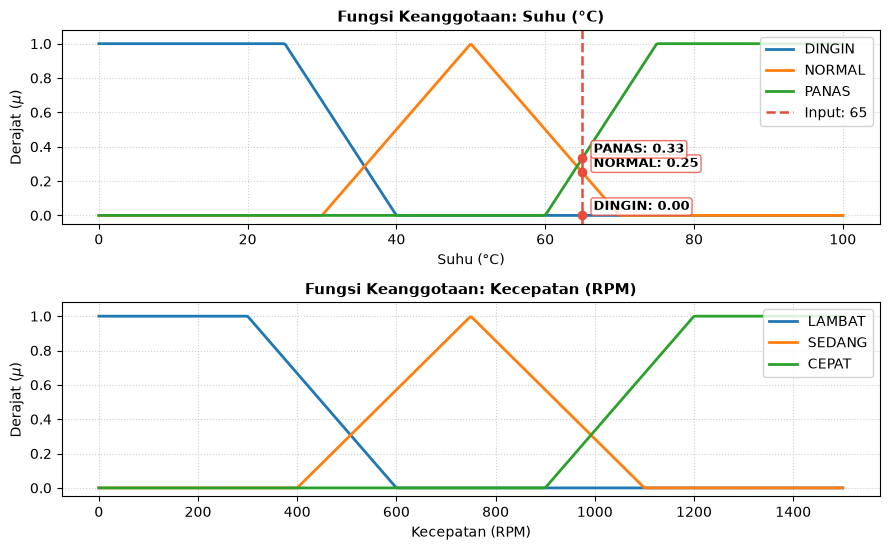

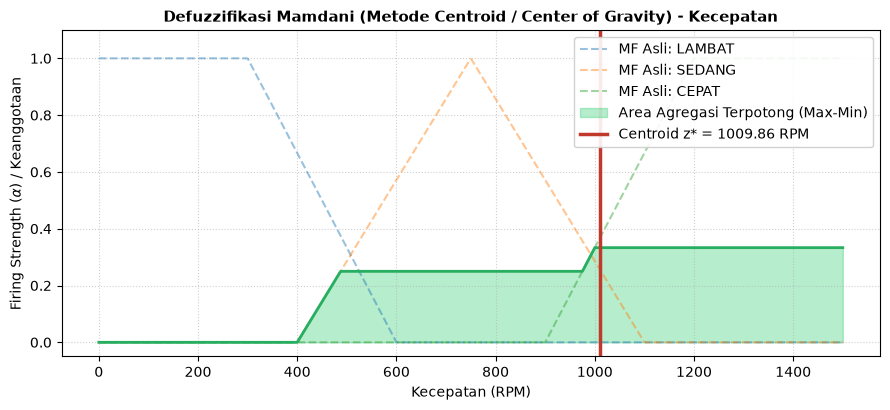



>>> STUDI KASUS BARU: SISTEM KENDALI KIPAS (METODE SUGENO) <<<
      HASIL SIMULASI KENDALI KIPAS (SUGENO)
Metode FIS  : Sugeno (Weighted Average)
Input Crisp : Suhu = 65
------------------------------------------------------------
1. Fuzzifikasi:
   [Suhu] -> DINGIN: 0.0000, NORMAL: 0.2500, PANAS: 0.3333
------------------------------------------------------------
2. Evaluasi Aturan (Firing Strength & z_i):
   * Rule R1 -> alpha_1 = 0.0000, z_1 = 300.00
   * Rule R2 -> alpha_2 = 0.2500, z_2 = 750.00
   * Rule R3 -> alpha_3 = 0.3333, z_3 = 1400.00
------------------------------------------------------------
3. Hasil Akhir Defuzzifikasi: z* = 1121.43 RPM


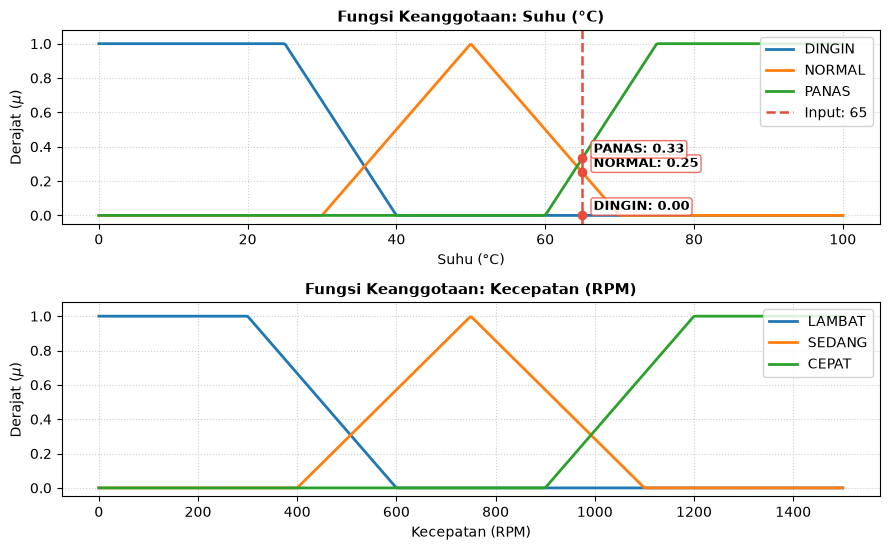

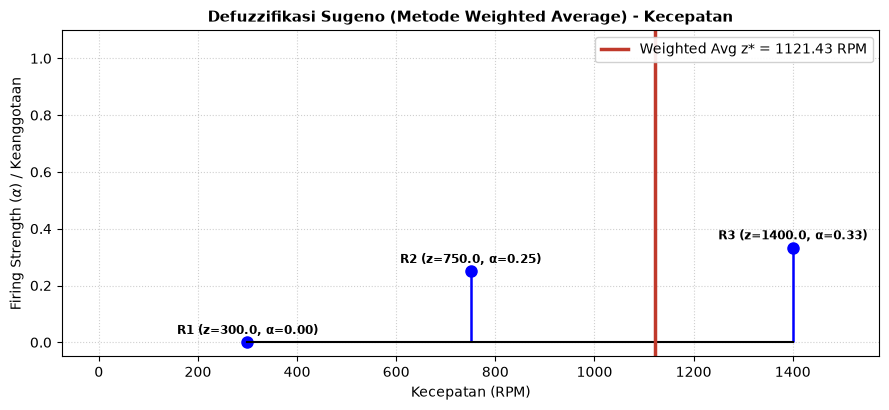

(1121.4285714285716,
 [(0.0, 300.0), (0.25, 750.0), (0.3333333333333333, 1400.0)],
 {'Suhu': {'DINGIN': 0.0, 'NORMAL': 0.25, 'PANAS': 0.3333333333333333}})

In [16]:
def build_cooling_fan_fis(method='mamdani'):
    """Membangun sistem kendali fuzzy untuk studi kasus kecepatan motor kipas pendingin."""
    fis = FuzzyInferenceSystem(method=method)

    # 1. Variabel Input: Suhu
    suhu = FuzzyVariable('Suhu', 0, 100, var_type='input', unit='°C')
    suhu.add_set('DINGIN', TrapezoidalMF(0, 0, 25, 40))
    suhu.add_set('NORMAL', TriangularMF(30, 50, 70))
    suhu.add_set('PANAS', TrapezoidalMF(60, 75, 100, 100))
    fis.add_variable(suhu)

    # 2. Variabel Output: Kecepatan Motor
    kecepatan = FuzzyVariable('Kecepatan', 0, 1500, var_type='output', unit='RPM')
    kecepatan.add_set('LAMBAT', TrapezoidalMF(0, 0, 300, 600))
    kecepatan.add_set('SEDANG', TriangularMF(400, 750, 1100))
    kecepatan.add_set('CEPAT', TrapezoidalMF(900, 1200, 1500, 1500))
    fis.add_variable(kecepatan)

    # 3. Basis Aturan Kendali (Mendukung Mamdani & Sugeno)
    fis.add_rule(FuzzyRule([('Suhu', 'DINGIN')], 'AND', 'Kecepatan', 'LAMBAT', inverse_func=300.0))
    fis.add_rule(FuzzyRule([('Suhu', 'NORMAL')], 'AND', 'Kecepatan', 'SEDANG', inverse_func=750.0))
    fis.add_rule(FuzzyRule([('Suhu', 'PANAS')], 'AND', 'Kecepatan', 'CEPAT', inverse_func=1400.0))

    return fis

# Contoh Pengujian Studi Kasus Baru: Suhu Ruangan = 65 °C
input_suhu = {'Suhu': 65}

print(">>> STUDI KASUS BARU: SISTEM KENDALI KIPAS (METODE MAMDANI) <<<")
fis_fan_mamdani = build_cooling_fan_fis(method='mamdani')
run_simulation(fis_fan_mamdani, input_suhu, title="HASIL SIMULASI KENDALI KIPAS (MAMDANI)")

print("\n" + "=" * 60 + "\n")

print(">>> STUDI KASUS BARU: SISTEM KENDALI KIPAS (METODE SUGENO) <<<")
fis_fan_sugeno = build_cooling_fan_fis(method='sugeno')
run_simulation(fis_fan_sugeno, input_suhu, title="HASIL SIMULASI KENDALI KIPAS (SUGENO)")